# 사용자 행동 인식(HAR) 다중분류 실습 답안

1. 데이터 구조 확인
2. 전처리 및 학습/평가용 데이터 준비
3. 베이스라인 모델 비교
4. 하이퍼파라미터 튜닝
5. 최종 모델 선정
6. 테스트셋 기준 성능 비교표 작성
7. 최종 모델 상세 평가

- `subject`는 사람 ID 성격이 강하므로 기본 실습에서는 입력 특성에서 제외한다.
- 스케일링이 필요한 모델과 필요하지 않은 모델을 구분하여 `Pipeline`으로 구성한다.
- 단순 정확도만 보지 않고, `Precision`, `Recall`, `F1-score`, `AUC(OVR)`까지 함께 비교한다.
- 최종 모델은 테스트셋 성능과 일반화 관점에서 선택한다.

## 1. 라이브러리 불러오기

- `scikit-learn`: 전처리, 모델링, 평가
- `xgboost`: 트리 기반 고성능 부스팅 모델
- `matplotlib`, `seaborn`: 시각화
- `pandas`, `numpy`: 데이터 처리

In [27]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from xgboost import XGBClassifier

## 2. 데이터 불러오기

이 데이터는 원래 UCI HAR 데이터셋을 가공한 형태이며, 센서 기반 특징량(feature)이 이미 많이 추출되어 있는 상태이다.
따라서 이 실습의 핵심은 딥러닝보다, 전통적인 머신러닝 분류 모델을 얼마나 잘 비교하고 선택하는가에 있다.

In [28]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)

display(train_df.head())

train shape: (7352, 563)
test shape : (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


## 3. 데이터 구조 확인

1. 타깃 컬럼이 무엇인가
2. 결측치가 있는가
3. 클래스 분포가 심하게 불균형한가
4. 사람 식별용 컬럼(`subject`)을 입력에 그대로 넣을 것인가

이번 실습에서는 `Activity`를 타깃으로 사용하고, `subject`는 사람 ID이므로 기본 모델 입력에서는 제외한다.

In [29]:
print(train_df.info())
print('\n컬럼 수:', len(train_df.columns))
print('타깃 고유값:', train_df['Activity'].unique())
print('결측치 총합(train):', train_df.isna().sum().sum())
print('결측치 총합(test) :', test_df.isna().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), str(1)
memory usage: 31.6 MB
None

컬럼 수: 563
타깃 고유값: <StringArray>
[          'STANDING',            'SITTING',             'LAYING',
            'WALKING', 'WALKING_DOWNSTAIRS',   'WALKING_UPSTAIRS']
Length: 6, dtype: str
결측치 총합(train): 0
결측치 총합(test) : 0


,count
Activity,
LAYING,1407
SITTING,1286
STANDING,1374
WALKING,1226
WALKING_DOWNSTAIRS,986
WALKING_UPSTAIRS,1073


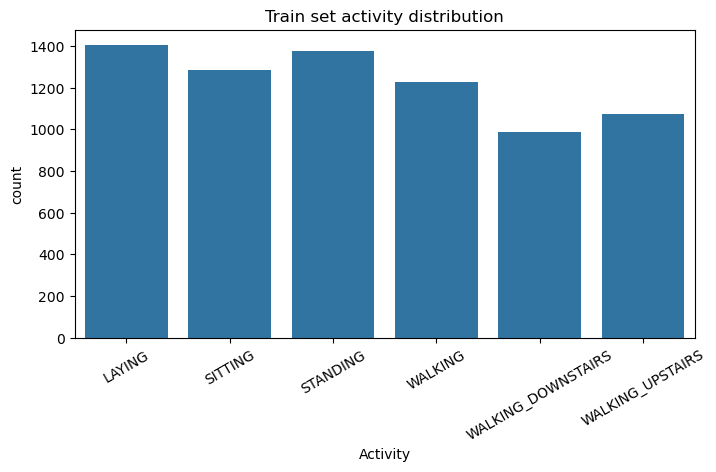

In [30]:
activity_counts = train_df['Activity'].value_counts().sort_index()
display(activity_counts.to_frame('count'))

plt.figure(figsize=(8, 4))
sns.countplot(data=train_df, x='Activity', order=sorted(train_df['Activity'].unique()))
plt.title('Train set activity distribution')
plt.xticks(rotation=30)
plt.show()

## 4. 학습용 / 평가용 데이터 준비

`subject`는 측정 대상 사람의 ID이다.
이 값이 들어가면 모델이 행동 패턴 자체보다 특정 사람의 특성을 학습할 가능성이 있다.
즉, 일반화 성능을 보기보다 사람 식별 정보에 기대는 방향으로 갈 수 있다.

따라서 다음처럼 처리한다.

- 입력 특성: `Activity`, `subject`를 제외한 모든 수치형 컬럼
- 타깃: `Activity`

또한 XGBoost 사용을 위해 타깃은 정수로 라벨 인코딩한다.

In [31]:
TARGET_COL = 'Activity'
DROP_COLS = ['Activity', 'subject']  # subject는 기본 실습에서 제외

X_train = train_df.drop(columns=DROP_COLS)
X_test = test_df.drop(columns=DROP_COLS)

y_train_raw = train_df[TARGET_COL]
y_test_raw = test_df[TARGET_COL]

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

class_names = label_encoder.classes_

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('classes:', class_names)

X_train: (7352, 561)
X_test : (2947, 561)
classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


## 5. 평가 함수 정의

다중분류에서는 정확도만 보면 부족하다.
클래스별 편차를 완화해서 보기 위해 `weighted average` 기준의 Precision, Recall, F1-score를 함께 계산한다.

AUC는 다중분류이므로 `One-vs-Rest(OVR)` 방식으로 계산한다.
- 확률값(`predict_proba`)이 있으면 그것을 사용
- 없으면 `decision_function`을 사용

In [32]:
def evaluate_multiclass_model(model, X_tr, y_tr, X_te, y_te, model_name='model'):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    result = {
        'Model Name': model_name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, average='weighted'),
        'Recall': recall_score(y_te, y_pred, average='weighted'),
        'F1-score': f1_score(y_te, y_pred, average='weighted')
    }

    # AUC 계산
    auc_value = np.nan
    try:
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_te)
            auc_value = roc_auc_score(y_te, y_score, multi_class='ovr', average='weighted')
        elif hasattr(model, 'decision_function'):
            y_score = model.decision_function(X_te)
            auc_value = roc_auc_score(y_te, y_score, multi_class='ovr', average='weighted')
    except Exception as e:
        print(f'[AUC 계산 생략] {model_name}:', e)

    result['AUC'] = auc_value
    return result

## 6. 베이스라인 모델 구성

1. Logistic Regression
2. Random Forest
3. KNN
4. SVM (RBF)
5. XGBoost

### 모델별 포인트

- Logistic Regression: 빠르고 강한 선형 베이스라인
- Random Forest: 트리 앙상블의 기본
- KNN: 거리 기반 모델, 스케일링 중요
- SVM(RBF): 고차원/복잡 경계에 강함, 스케일링 필수
- XGBoost: 고성능 부스팅 모델, 표 형식 데이터에서 강력함

In [ ]:
baseline_models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # 결측값을 각 컬럼의 중앙값으로 채움
        ('scaler', StandardScaler()),                    # 특성 스케일을 맞춰 모델 학습을 안정화
        ('model', LogisticRegression(
            max_iter=3000,                               # 반복 횟수를 늘려 수렴이 안 되는 상황을 방지
            random_state=42                              # 실행할 때마다 같은 결과가 나오도록 고정
        ))
    ]),

    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # 결측값을 중앙값으로 채움
        ('model', RandomForestClassifier(
            n_estimators=300,                            # 트리 300개를 만들어 앙상블
            random_state=42,                             # 결과 재현을 위한 시드 고정
            n_jobs=-1                                    # 가능한 모든 CPU 코어 사용
        ))
    ]),

    'KNN (k=5)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # 결측값을 중앙값으로 채움
        ('scaler', StandardScaler()),                    # 거리 기반 모델이므로 스케일링이 중요
        ('model', KNeighborsClassifier(n_neighbors=5))   # 가장 가까운 5개 이웃을 기준으로 분류
    ]),

    'SVM (RBF)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # 결측값을 중앙값으로 채움
        ('scaler', StandardScaler()),                    # SVM은 스케일 차이에 민감하므로 정규화 필요
        ('model', SVC(
            kernel='rbf',                                # 비선형 경계를 만들기 위한 RBF 커널 사용
            C=1.0,                                       # 오차 허용과 마진 크기 사이의 균형 조절
            gamma='scale',                               # 데이터 분산을 반영해 커널 영향 범위 자동 설정
            probability=True,                            # predict_proba 사용 가능하도록 확률값 계산 활성화
            random_state=42                              # 결과 재현을 위한 시드 고정
        ))
    ]),

    'XGBoost': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # 결측값을 중앙값으로 채움
        ('model', XGBClassifier(
            objective='multi:softprob',                  # 다중분류에서 클래스별 확률값 출력
            num_class=len(class_names),                  # 분류할 클래스 개수 지정
            eval_metric='mlogloss',                      # 다중분류용 로그손실 기준으로 평가
            n_estimators=300,                            # 부스팅 트리 300개 사용
            learning_rate=0.1,                           # 한 번에 얼마나 조금씩 학습할지 설정
            max_depth=6,                                 # 각 트리의 최대 깊이 제한
            subsample=0.9,                               # 매 트리마다 데이터의 90%만 사용
            colsample_bytree=0.9,                        # 매 트리마다 특성의 90%만 사용
            tree_method='hist',                          # 히스토그램 기반 분할로 학습 속도 개선
            random_state=42,                             # 결과 재현을 위한 시드 고정
            n_jobs=-1                                    # 가능한 모든 CPU 코어 사용
        ))
    ])
}

## 7. 베이스라인 모델 성능 비교

- 튜닝 전 기본값/준기본값 상태에서 먼저 비교한다.
- 이 결과는 “어떤 계열이 강한가?”를 보는 출발점이다.
- 여기서 성능이 좋은 모델 위주로 튜닝 우선순위를 잡으면 된다.

In [34]:
baseline_results = []

for model_name, model in baseline_models.items():
    print(f'학습 중: {model_name}')
    result = evaluate_multiclass_model(
        model, X_train, y_train, X_test, y_test, model_name=model_name
    )
    baseline_results.append(result)

baseline_df = pd.DataFrame(baseline_results).sort_values(by='F1-score', ascending=False)
display(baseline_df)

학습 중: Logistic Regression
학습 중: Random Forest
학습 중: KNN (k=5)
학습 중: SVM (RBF)
학습 중: XGBoost


,Model Name,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.954530,0.956364,0.954530,0.954466,0.997487
3,SVM (RBF),0.951815,0.952236,0.951815,0.951711,0.997645
4,XGBoost,0.940278,0.941717,0.940278,0.940105,0.997400
1,Random Forest,0.928741,0.929827,0.928741,0.928525,0.995675
2,KNN (k=5),0.883610,0.890576,0.883610,0.882687,0.976437


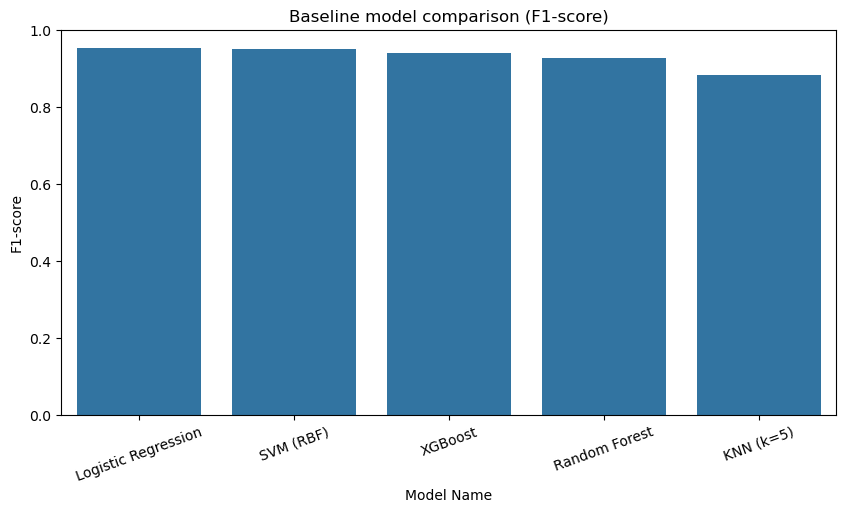

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(data=baseline_df, x='Model Name', y='F1-score')
plt.title('Baseline model comparison (F1-score)')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

## 8. 하이퍼파라미터 튜닝 전략

전체 모델을 크게 탐색하면 시간이 많이 걸린다.
그래서 이 노트북은 튜닝을 두 가지 모드로 구분한다.

1. QUICK 모드
- 빠르게 결과를 확인하기 위한 초경량 버전이다.
- 수업 시간 실습이나 노트북 사양이 낮을 때 먼저 사용한다.
- 탐색 조합 수, CV 횟수, 병렬 작업 수를 크게 줄여 실행 부담을 낮춘다.

2. FULL 모드
- 더 넓은 하이퍼파라미터 범위를 탐색하는 정규 버전이다.
- 성능을 조금 더 끌어올릴 수 있지만 시간이 더 오래 걸린다.

튜닝 대상은 다음 4개 모델이다.
- Logistic Regression
- Random Forest
- SVM (RBF)
- XGBoost

KNN은 비교용 베이스라인으로는 좋지만,
이 데이터에서는 보통 선형 모델/SVM/부스팅 계열이 더 강한 경우가 많아 튜닝 우선순위를 뒤로 둔다.


### 튜닝 모드 안내

- `TUNING_MODE = 'quick'`: 빠른 확인용 초경량 버전
- `TUNING_MODE = 'full'`: 정규 탐색 버전

기본값은 실행 편의를 위해 `quick`으로 둔다.


In [ ]:
TUNING_MODE = 'quick'   # 'quick' 또는 'full'

if TUNING_MODE == 'quick':
    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    parallel_jobs = 1
elif TUNING_MODE == 'full':
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    parallel_jobs = -1
else:
    raise ValueError("TUNING_MODE는 'quick' 또는 'full' 이어야 합니다.")

print('현재 튜닝 모드:', TUNING_MODE)
print('CV fold 수:', cv.get_n_splits())
print('병렬 작업 수:', parallel_jobs)


현재 튜닝 모드: full
CV fold 수: 5
병렬 작업 수: -1


In [37]:
if TUNING_MODE == 'quick':
    # 빠른 확인용 초경량 버전
    logreg_param_grid = {
        'model__C': [0.3, 1.0],
        'model__solver': ['lbfgs']
    }

    rf_param_dist = {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 20],
        'model__min_samples_split': [2, 5]
    }

    svm_param_dist = {
        'model__C': [1, 3],
        'model__gamma': ['scale', 0.01]
    }

    xgb_param_dist = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth': [4, 6]
    }

    rf_n_iter = 2
    svm_n_iter = 2
    xgb_n_iter = 2

else:
    # 정규 탐색 버전
    logreg_param_grid = {
        'model__C': [0.01, 0.1, 1, 3, 10, 30],
        'model__solver': ['lbfgs', 'saga']
    }

    rf_param_dist = {
        'model__n_estimators': [200, 300, 500, 700],
        'model__max_depth': [None, 15, 20, 30, 40],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2', 0.5]
    }

    svm_param_dist = {
        'model__C': [0.1, 0.3, 1, 3, 10, 30, 100],
        'model__gamma': ['scale', 0.0003, 0.001, 0.01, 0.1]
    }

    xgb_param_dist = {
        'model__n_estimators': [200, 300, 500, 700],
        'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'model__max_depth': [3, 4, 6, 8, 10],
        'model__subsample': [0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'model__min_child_weight': [1, 3, 5, 7]
    }

    rf_n_iter = 20
    svm_n_iter = 15
    xgb_n_iter = 20

print('LogisticRegression 조합 수:', len(logreg_param_grid['model__C']) * len(logreg_param_grid['model__solver']))
print('RandomForest n_iter:', rf_n_iter)
print('SVM n_iter:', svm_n_iter)
print('XGBoost n_iter:', xgb_n_iter)


LogisticRegression 조합 수: 12
RandomForest n_iter: 20
SVM n_iter: 15
XGBoost n_iter: 20


## 9. 모델별 튜닝 수행

평가지표는 `f1_weighted`를 사용한다.
이유는 다중분류에서 전체 정확도만으로는 클래스별 성능을 충분히 보기 어렵기 때문이다.

또한 교차검증은 `train` 데이터에서만 수행한다.
테스트셋은 최종 확인용으로 남겨 둔다.

먼저 `quick` 모드로 전체 흐름과 결과를 확인하고,
시간이 충분할 때 `full` 모드로 확장하는 흐름을 권장한다.

In [38]:
tuning_objects = {}

# 1) Logistic Regression
logreg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=3000,
        random_state=42
    ))
])

tuning_objects['Logistic Regression (tuned)'] = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=parallel_jobs,
    verbose=1
)

# 2) Random Forest
rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        random_state=42,
        n_jobs=parallel_jobs
    ))
])

tuning_objects['Random Forest (tuned)'] = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=rf_n_iter,
    scoring='f1_weighted',
    cv=cv,
    random_state=42,
    n_jobs=parallel_jobs,
    verbose=1
)

# 3) SVM (RBF)
# quick 모드에서는 probability=False로 두어 속도 부담을 줄인다.
# AUC는 decision_function으로 계산 가능하다.
svm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVC(
        kernel='rbf',
        probability=(TUNING_MODE == 'full'),
        random_state=42
    ))
])

tuning_objects['SVM (RBF, tuned)'] = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=svm_param_dist,
    n_iter=svm_n_iter,
    scoring='f1_weighted',
    cv=cv,
    random_state=42,
    n_jobs=parallel_jobs,
    verbose=1
)

# 4) XGBoost
xgb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        objective='multi:softprob',
        num_class=len(class_names),
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_jobs=parallel_jobs
    ))
])

tuning_objects['XGBoost (tuned)'] = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=xgb_n_iter,
    scoring='f1_weighted',
    cv=cv,
    random_state=42,
    n_jobs=parallel_jobs,
    verbose=1
)

print('튜닝 대상 모델 수:', len(tuning_objects))
print('튜닝 대상:', list(tuning_objects.keys()))


튜닝 대상 모델 수: 4
튜닝 대상: ['Logistic Regression (tuned)', 'Random Forest (tuned)', 'SVM (RBF, tuned)', 'XGBoost (tuned)']


In [39]:
best_estimators = {}
cv_summary = []

for idx, (name, searcher) in enumerate(tuning_objects.items(), start=1):
    print('=' * 80)
    print(f'[{idx}/{len(tuning_objects)}] 튜닝 시작: {name}')
    searcher.fit(X_train, y_train)

    print('best params:', searcher.best_params_)
    print('best cv score:', searcher.best_score_)

    best_estimators[name] = searcher.best_estimator_
    cv_summary.append({
        'Model Name': name,
        'Best CV F1': searcher.best_score_,
        'Best Params': searcher.best_params_
    })

print('=' * 80)
print('튜닝 완료')


[1/4] 튜닝 시작: Logistic Regression (tuned)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
best params: {'model__C': 1, 'model__solver': 'lbfgs'}
best cv score: 0.9847591877045346
[2/4] 튜닝 시작: Random Forest (tuned)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
best params: {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 40}
best cv score: 0.9819068785685305
[3/4] 튜닝 시작: SVM (RBF, tuned)
Fitting 5 folds for each of 15 candidates, totalling 75 fits
best params: {'model__gamma': 'scale', 'model__C': 3}
best cv score: 0.9832668084724807
[4/4] 튜닝 시작: XGBoost (tuned)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
best params: {'model__subsample': 1.0, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
best cv score: 0.9922445238161123
튜닝 완료


In [40]:
cv_summary_df = pd.DataFrame(cv_summary).sort_values(by='Best CV F1', ascending=False)
display(cv_summary_df)

,Model Name,Best CV F1,Best Params
3,XGBoost (tuned),0.992245,"{'model__subsample': 1.0, 'model__n_estimators..."
0,Logistic Regression (tuned),0.984759,"{'model__C': 1, 'model__solver': 'lbfgs'}"
2,"SVM (RBF, tuned)",0.983267,"{'model__gamma': 'scale', 'model__C': 3}"
1,Random Forest (tuned),0.981907,"{'model__n_estimators': 300, 'model__min_sampl..."


## 10. 튜닝 완료 모델의 테스트셋 성능 비교

교차검증에서 선택된 최적 설정으로
테스트셋에 대해 Accuracy, Precision, Recall, F1-score, AUC를 다시 계산한다.

이 표가 최종 비교표가 된다.

In [41]:
tuned_results = []

for model_name, model in best_estimators.items():
    result = evaluate_multiclass_model(
        model, X_train, y_train, X_test, y_test, model_name=model_name
    )
    tuned_results.append(result)

tuned_df = pd.DataFrame(tuned_results).sort_values(by='F1-score', ascending=False)
display(tuned_df)

,Model Name,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression (tuned),0.954530,0.956364,0.954530,0.954466,0.997487
2,"SVM (RBF, tuned)",0.952833,0.953618,0.952833,0.952672,0.997717
3,XGBoost (tuned),0.950458,0.951685,0.950458,0.950304,0.998106
1,Random Forest (tuned),0.939600,0.941311,0.939600,0.939202,0.996560


## 11. 베이스라인 vs 튜닝 결과 통합 비교

단순히 최종 최고 성능만 보는 것보다,
튜닝 전후가 얼마나 달라졌는지 비교하는 것이 중요하다.

In [42]:
all_results_df = pd.concat([
    baseline_df.assign(Type='Baseline'),
    tuned_df.assign(Type='Tuned')
], ignore_index=True)

all_results_df = all_results_df.sort_values(by='F1-score', ascending=False).reset_index(drop=True)
display(all_results_df)

,Model Name,Accuracy,Precision,Recall,F1-score,AUC,Type
0,Logistic Regression,0.954530,0.956364,0.954530,0.954466,0.997487,Baseline
1,Logistic Regression (tuned),0.954530,0.956364,0.954530,0.954466,0.997487,Tuned
2,"SVM (RBF, tuned)",0.952833,0.953618,0.952833,0.952672,0.997717,Tuned
3,SVM (RBF),0.951815,0.952236,0.951815,0.951711,0.997645,Baseline
4,XGBoost (tuned),0.950458,0.951685,0.950458,0.950304,0.998106,Tuned
5,XGBoost,0.940278,0.941717,0.940278,0.940105,0.997400,Baseline
6,Random Forest (tuned),0.939600,0.941311,0.939600,0.939202,0.996560,Tuned
7,Random Forest,0.928741,0.929827,0.928741,0.928525,0.995675,Baseline
8,KNN (k=5),0.883610,0.890576,0.883610,0.882687,0.976437,Baseline


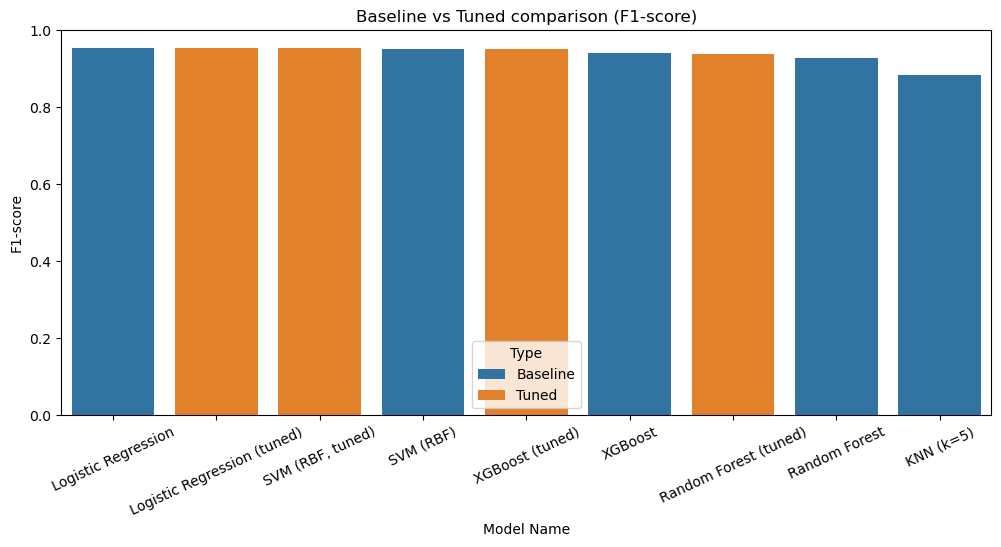

In [43]:
plt.figure(figsize=(12, 5))
sns.barplot(data=all_results_df, x='Model Name', y='F1-score', hue='Type')
plt.title('Baseline vs Tuned comparison (F1-score)')
plt.xticks(rotation=25)
plt.ylim(0, 1)
plt.show()

## 12. 최종 모델 선택

1. 테스트셋 `F1-score`가 가장 높은 모델
2. 동점 수준이면 `Accuracy`, `AUC`도 함께 고려
3. 성능 차이가 매우 작다면 학습 시간과 해석 가능성도 고려

보통 HAR 데이터셋에서는 선형 모델, SVM, 부스팅 계열이 매우 강하게 나오는 경우가 많다.
실제 최고 모델은 실행 결과에 따라 결정하되, 대체로 `SVM(RBF)` 또는 `XGBoost`가 강력한 후보가 된다.

In [44]:
best_row = tuned_df.sort_values(by=['F1-score', 'Accuracy', 'AUC'], ascending=False).iloc[0]
best_model_name = best_row['Model Name']
best_model = best_estimators[best_model_name]

print('최종 선택 모델:', best_model_name)
display(best_row.to_frame().T)

최종 선택 모델: Logistic Regression (tuned)


,Model Name,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression (tuned),0.95453,0.956364,0.95453,0.954466,0.997487


- 테스트셋 기준 F1-score가 가장 높다.
- Accuracy도 최고 수준이다.
- AUC는 XGBoost가 약간 더 높지만, F1-score와 Accuracy를 함께 보면 Logistic Regression이 더 균형 잡힌 결과를 보였다.
- 모델 구조가 단순하고 학습 및 추론 비용이 상대적으로 작다.
- 해석 가능성 측면에서도 다른 복잡한 비선형 모델보다 유리하다.

## 13. 최종 모델 상세 평가

1. 분류 리포트
2. 혼동행렬
3. 어떤 클래스에서 헷갈리는지

이 과정을 통해 단순 수치 비교를 넘어 모델이 실제로 어떤 행동을 구분하기 어려워하는지 해석할 수 있다.

In [45]:
# 최종 모델 재학습 및 예측
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=class_names))

                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       537
           SITTING       0.97      0.87      0.92       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.96      0.95      0.95       471

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947



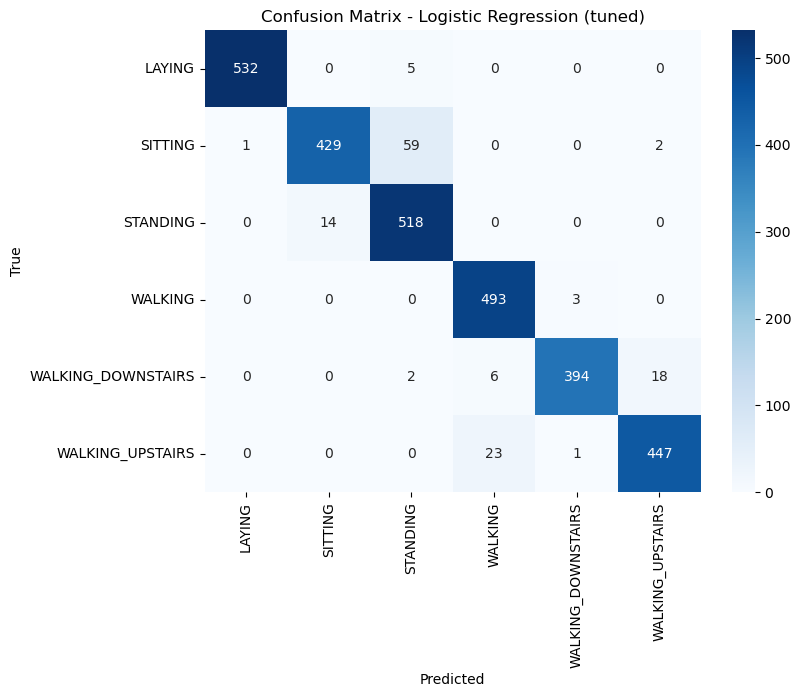

In [46]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

분류 리포트와 혼동행렬을 보면 전체 정확도와 weighted F1-score는 약 0.95 수준으로 매우 우수하다.
특히 LAYING, WALKING, WALKING_DOWNSTAIRS 클래스는 높은 정밀도와 재현율을 보여 비교적 안정적으로 구분되었다.

반면 SITTING과 STANDING 사이에서는 일부 혼동이 나타난다.
예를 들어 SITTING이 STANDING으로 예측된 경우가 59건 있었고,
STANDING이 SITTING으로 예측된 경우도 14건 있었다.
이 두 클래스는 모두 정적인 자세이며 센서 패턴이 유사할 수 있어, 모델이 상대적으로 구분을 어려워한 것으로 해석할 수 있다.

또한 WALKING_UPSTAIRS와 WALKING, WALKING_DOWNSTAIRS 사이에도 일부 혼동이 보인다.
예를 들어 WALKING_UPSTAIRS가 WALKING으로 예측된 경우가 23건 있었고,
WALKING_DOWNSTAIRS가 WALKING_UPSTAIRS로 예측된 경우도 18건 있었다.
이 역시 모두 보행 계열 동작이기 때문에 움직임 패턴이 일정 부분 비슷하여 경계가 완전히 분리되지 않은 것으로 볼 수 있다.

즉, 최종 모델은 전반적으로 매우 높은 성능을 보였지만,
정적인 자세끼리 또는 유사한 보행 동작끼리 일부 혼동이 남아 있었다.
이는 모델의 한계라기보다 클래스 자체의 특성 유사성에서 비롯된 자연스러운 결과로 해석할 수 있다.

## 14. 최종 비교표 만들기

문제에서 요구한 형식에 맞춰 최종 비교표를 보기 좋게 정리한다.

`기타 메모`에는 모델 특징 또는 튜닝 포인트를 함께 남긴다.

In [47]:
memo_map = {
    'Logistic Regression': '베이스라인 선형 모델',
    'Random Forest': '트리 앙상블 기본 비교',
    'KNN (k=5)': '거리기반, 표준화 중요',
    'SVM (RBF)': '비선형 경계, 표준화 필수',
    'XGBoost': '부스팅 기반 고성능 후보',
    'Logistic Regression (tuned)': 'C, solver 튜닝',
    'Random Forest (tuned)': '트리 수/깊이/분할 조건 튜닝',
    'SVM (RBF, tuned)': 'C, gamma 튜닝',
    'XGBoost (tuned)': 'depth, learning_rate, subsample 등 튜닝'
}

submission_table = all_results_df.copy()
submission_table['Memo'] = submission_table['Model Name'].map(memo_map)

# 보기 좋게 반올림
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
submission_table[metric_cols] = submission_table[metric_cols].round(4)

display(submission_table[['Model Name', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC', 'Memo']])

,Model Name,Accuracy,Precision,Recall,F1-score,AUC,Memo
0,Logistic Regression,0.9545,0.9564,0.9545,0.9545,0.9975,베이스라인 선형 모델
1,Logistic Regression (tuned),0.9545,0.9564,0.9545,0.9545,0.9975,"C, solver 튜닝"
2,"SVM (RBF, tuned)",0.9528,0.9536,0.9528,0.9527,0.9977,"C, gamma 튜닝"
3,SVM (RBF),0.9518,0.9522,0.9518,0.9517,0.9976,"비선형 경계, 표준화 필수"
4,XGBoost (tuned),0.9505,0.9517,0.9505,0.9503,0.9981,"depth, learning_rate, subsample 등 튜닝"
5,XGBoost,0.9403,0.9417,0.9403,0.9401,0.9974,부스팅 기반 고성능 후보
6,Random Forest (tuned),0.9396,0.9413,0.9396,0.9392,0.9966,트리 수/깊이/분할 조건 튜닝
7,Random Forest,0.9287,0.9298,0.9287,0.9285,0.9957,트리 앙상블 기본 비교
8,KNN (k=5),0.8836,0.8906,0.8836,0.8827,0.9764,"거리기반, 표준화 중요"


## 정리

1. 다중분류에서는 정확도 하나만 보면 부족하다.
2. 스케일링이 필요한 모델과 그렇지 않은 모델을 구분해야 한다.
3. `Pipeline`을 쓰면 전처리와 모델링을 한 흐름으로 묶을 수 있다.
4. 하이퍼파라미터 튜닝은 반드시 `train` 데이터 내부의 교차검증으로 수행해야 한다.
5. 최종 평가는 마지막에 `test` 데이터로 한 번만 수행하는 것이 바람직하다.
6. HAR처럼 특징량이 잘 정리된 표 데이터에서는 SVM, 선형모델, 부스팅 계열이 강력한 후보가 된다.